In [ ]:
!pip install wget

# Multi-class Classification Using Softmax Regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import confusion_matrix

cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(cmap.N)]

mpl.rcParams["font.size"] = 24
mpl.rcParams["lines.linewidth"] = 2

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

#import os
#os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

Device: cpu


## Load Dataset

In [3]:
!python -m wget https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv \
    --output delaney-processed.csv


Saved under delaney-processed (1).csv


In [4]:
DELANEY_FILE = "delaney-processed.csv"
TASK_COL = 'measured log solubility in mols per litre'
df = pd.read_csv(DELANEY_FILE)
print(f"Number of molecules in the dataset: {df.shape[0]}")

Number of molecules in the dataset: 1128


## Input data

X: input feature values
Y: True labels

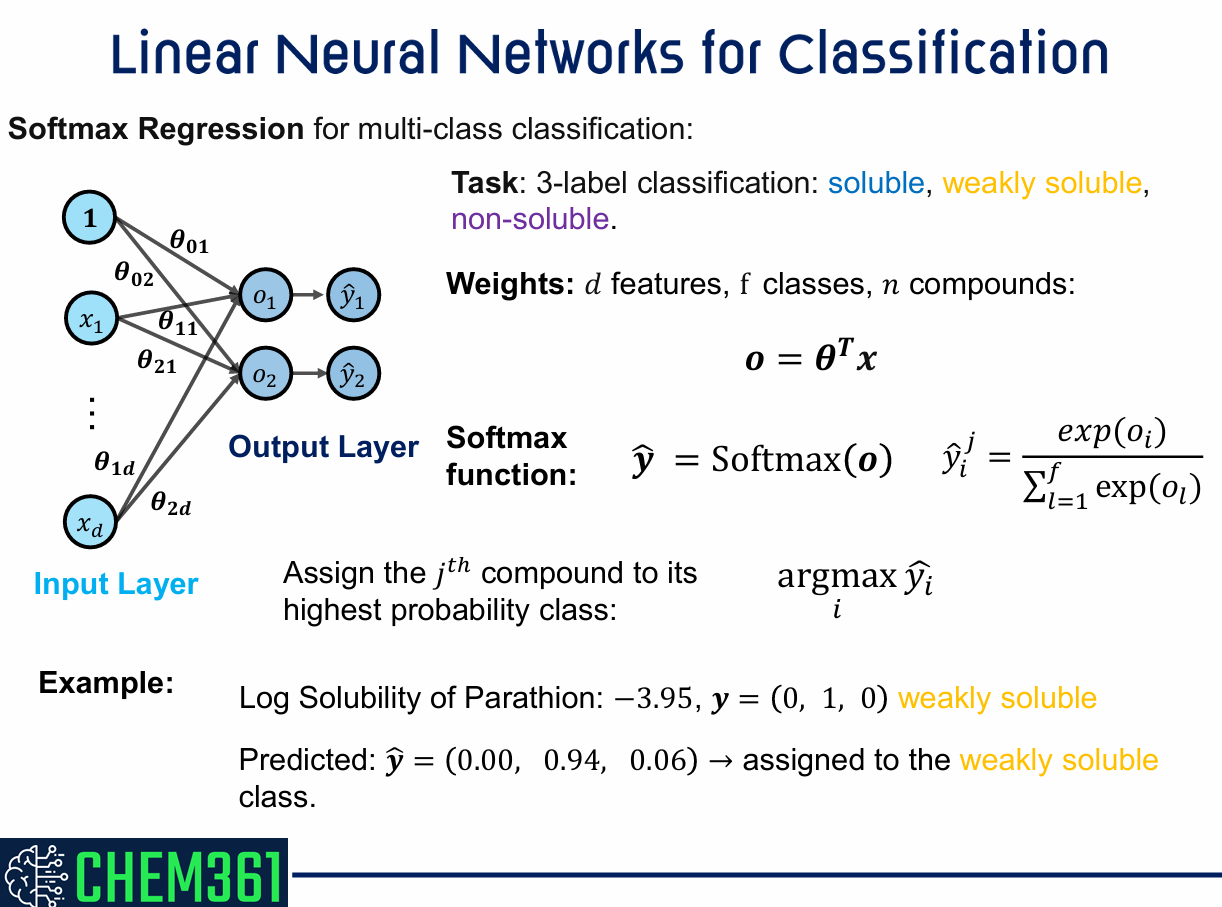

In [5]:
def assign_label(x):
    if x >= -2:
        return 0
    elif x < -2 and x >= -4:
        return 1
    else:
        return 2

df["soluble"] = df[TASK_COL].apply(assign_label)


n_class = 3
X = df[[
        "Molecular Weight",
        "Polar Surface Area"]].values
onehot = np.eye(n_class)
Y = df["soluble"].values
Y_onehot = onehot[Y]
Y = Y_onehot
print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (1128, 2)
Shape of Y: (1128, 3)


([<matplotlib.axis.XTick at 0x7ad5f6347510>,
 [Text(0, 0, 'Soluble [-2, $\\inf$)'),
  Text(1, 0, 'Weakly Soluble [-4, -2)'),
  Text(2, 0, 'Insoluble (-$\\inf$, -4)')])

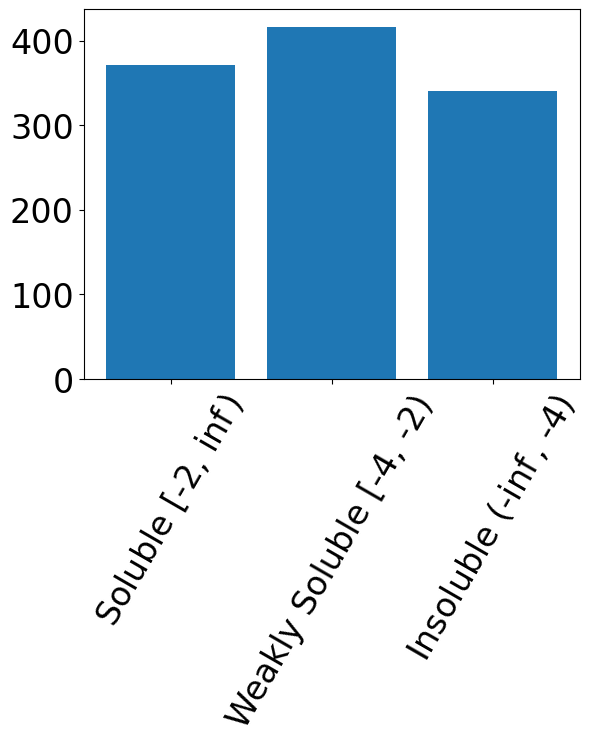

In [6]:
plt.bar(range(n_class), np.sum(Y, axis=0))
plt.xticks(range(n_class), [r"Soluble [-2, $\inf$)",
                            "Weakly Soluble [-4, -2)",
                            r"Insoluble (-$\inf$, -4)"], rotation=60)

In [7]:
from sklearn.model_selection import train_test_split

# training/validation dataset
test_size = int(len(X)*0.1)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=test_size, shuffle=True)

# create dataloaders
X_train, X_test, y_train, y_test = map(torch.tensor, (X_train, X_test, y_train, y_test))
batch_size = 128 #batch size in minibatch gradient descent
train_data = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
                                           shuffle=True, drop_last=False)
test_data = torch.utils.data.TensorDataset(X_test, y_test)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
                                          shuffle=False, drop_last=False)

## Training Utils

In [8]:
# Define linear regression model
class LinearRegresion(torch.nn.Module):
    def __init__(self, indim, outdim):
        super(LinearRegresion, self).__init__()
        self.norm = nn.BatchNorm1d(indim)
        self.linear = torch.nn.Linear(indim, outdim)
    def forward(self, x):
        x = self.norm(x)
        x = self.linear(x)
        return x

def train_one_epcoh(model, criterion, optimizer, dataloader):
    losses = []
    model.train()
    for x, y_true in dataloader:
        if device == "cuda":
            x, y_true = x.to(device), y_true.to(device)
        x, y_true = x.float(), y_true.float()
        optimizer.zero_grad()
        y_pred = model(x) # we will choose linear regression model for forward propagation
        y_pred = nn.Softmax(dim=-1)(y_pred)
        loss = criterion(y_pred, y_true)
        loss.backward() #backprogatation
        optimizer.step() #backprogatation
        losses.append(loss.cpu().detach().item())
    return losses

# no backpropagation in the validation/testing runs
def val_one_epcoh(model, criterion, dataloader):
    losses = []
    model.eval()
    with torch.no_grad():
        for x, y_true in dataloader:
            if device == "cuda":
                x, y_true = x.to(device), y_true.to(device)
            x, y_true = x.float(), y_true.float()
            y_pred = model(x)
            y_pred = nn.Softmax(dim=-1)(y_pred)
            loss = criterion(y_pred, y_true)
            losses.append(loss.cpu().detach().item())
    return losses


## Training Softmax Regression models

In [9]:
model = LinearRegresion(X.shape[-1], n_class)
model = model.to(device)
model = model.float()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05) #learning rate: lr
n_epochs = 1000

train_loss = []
val_loss = []

for epoch in range(n_epochs):
    losses = train_one_epcoh(model, criterion, optimizer, train_loader)
    train_loss.append(np.mean(losses))
    losses = val_one_epcoh(model, criterion, test_loader)
    val_loss.append(np.mean(losses))


### Plotting training Curve

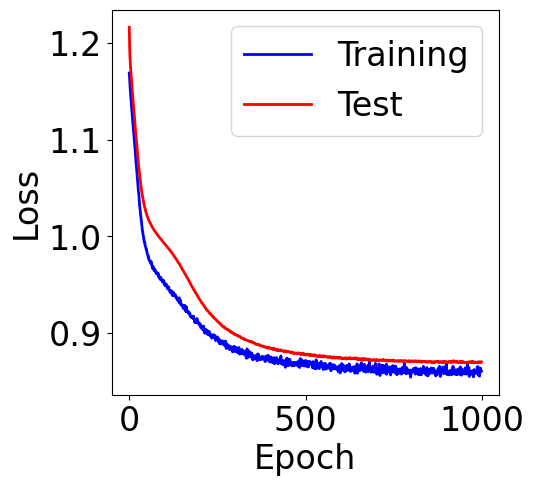

In [10]:
f, ax = plt.subplots(1, 1, figsize=(5,5))

ax.plot(train_loss, c="blue", label="Training")
ax.plot(val_loss, c="red", label="Test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


### Visualize Decision Boundaries

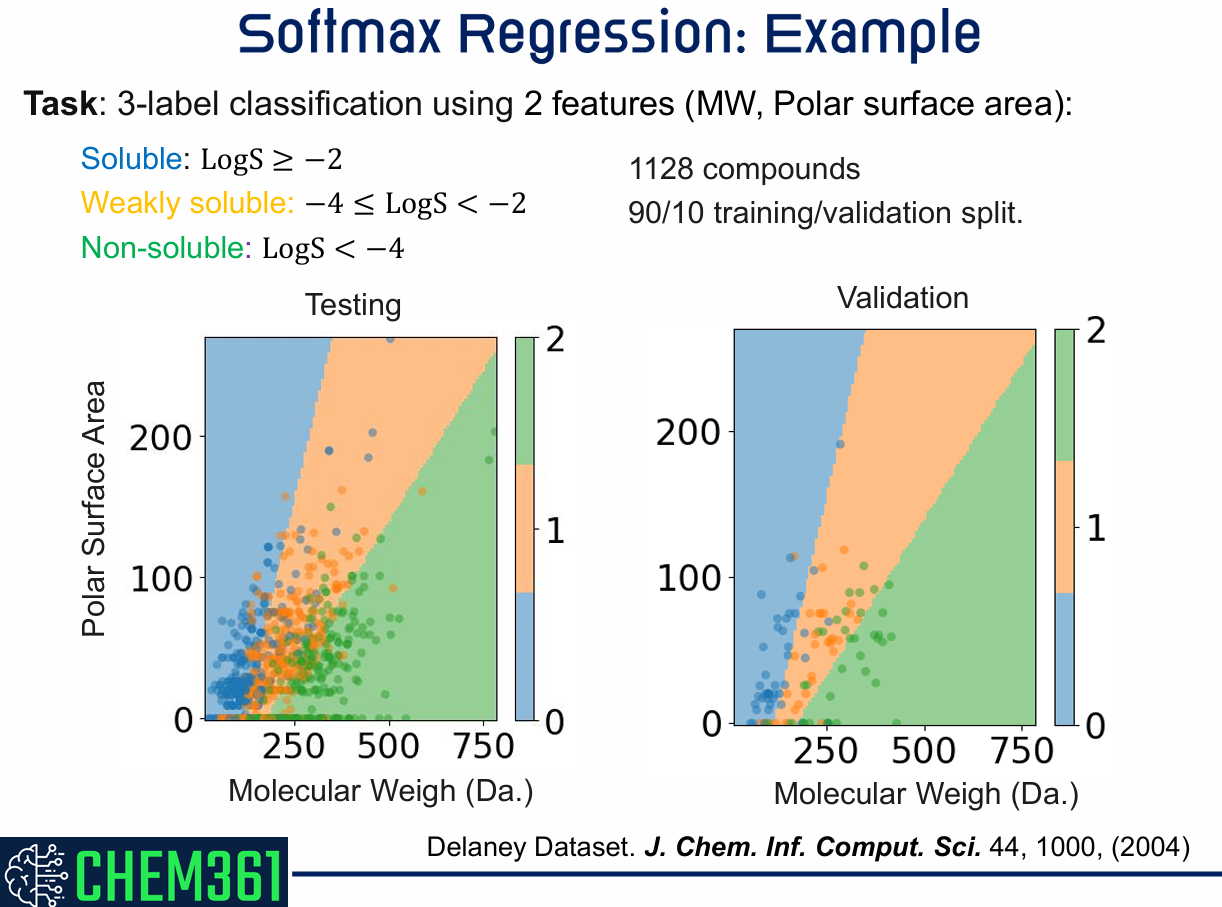

In [11]:
# grid data for visualization
x_min, x_max = X_train[:, 0].min(), X_train[:, 0].max()
y_min, y_max = X_train[:, 1].min(), X_train[:, 1].max()

x_min = x_min.item()
y_min = y_min.item()
x_max = x_max.item()
y_max = y_max.item()

xx = np.linspace(x_min, x_max, 100)
yy = np.linspace(y_min, y_max, 100)

xx, yy = np.meshgrid(xx, yy)
grids = np.hstack([xx.ravel().reshape(-1, 1), yy.ravel().reshape(-1, 1)])

grid_data = torch.utils.data.TensorDataset(
    torch.tensor(grids).float()
)
grid_loader = torch.utils.data.DataLoader(grid_data, batch_size=batch_size,
                                          shuffle=False, drop_last=False)

In [12]:
predictions = []
model.eval()
with torch.no_grad():
    for x, in grid_loader:
        if device == "cuda":
            x = x.to(device)
        x = x.float()
        y_pred = model(x)
        y_pred = nn.Softmax(dim=-1)(y_pred)
        y_pred = torch.argmax(y_pred, dim=-1)
        predictions.extend([y_pred[i].item() for i in range(len(y_pred))])

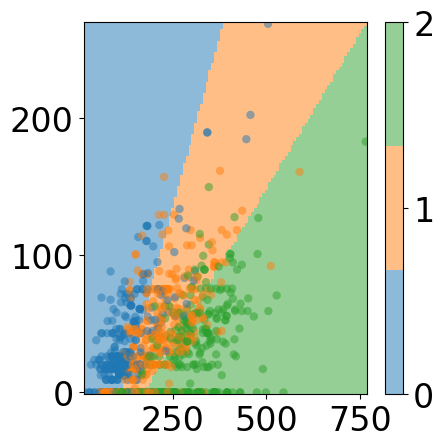

In [13]:
# plot space separation
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

custom_cmap = ListedColormap([cmap(0), cmap(1), cmap(2)])
mesh_pred = np.array(predictions).reshape(xx.shape)
plt.pcolormesh(xx, yy, mesh_pred,
              cmap=custom_cmap, alpha=0.5)
plt.scatter([v.item() for v in X_train[:, 0]], [v.item() for v in X_train[:, -1]],
            c=[torch.argmax(y_train[i]).item() for i in range(len(y_train))], cmap=custom_cmap,
            edgecolors='none', alpha=0.5)
cbar = plt.colorbar(ticks=[0, 1, 2])
# plt.title("Training Data and Decision Boundary")
fig.tight_layout()

Text(0.5, 1.0, 'Validation Data')

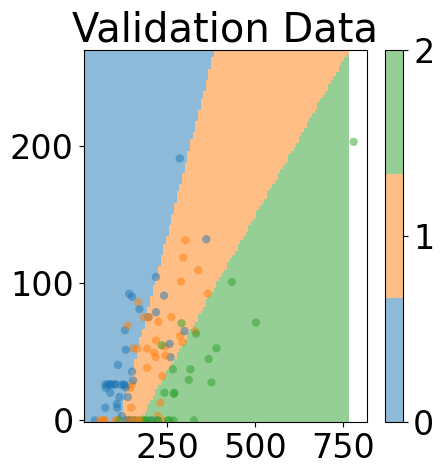

In [14]:
# plot space separation
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

custom_cmap = ListedColormap([cmap(0), cmap(1), cmap(2)])
mesh_pred = np.array(predictions).reshape(xx.shape)
plt.pcolormesh(xx, yy, mesh_pred,
              cmap=custom_cmap, alpha=0.5)
plt.scatter([v.item() for v in X_test[:, 0]], [v.item() for v in X_test[:, -1]],
           c=[torch.argmax(y_test[i]).item() for i in range(len(y_test))], cmap=custom_cmap,
            edgecolors='none', alpha=0.5)
cbar = plt.colorbar(ticks=[0, 1, 2])
fig.tight_layout()
plt.title("Validation Data")

### Confusion Matrix

In [15]:
y_test_pred = []
y_test_true = []
model.eval()
with torch.no_grad():
    for x,y in test_loader:
        if device == "cuda":
            x = x.to(device)
        x = x.float()
        y_test_true.extend([torch.argmax(y[i]).item() for i in range(len(y))])
        y_pred = model(x)
        y_pred = nn.Softmax(dim=-1)(y_pred)
        y_pred = torch.argmax(y_pred, dim=-1)
        y_test_pred.extend([y_pred[i].item() for i in range(len(y_pred))])

In [16]:
confusion_matrix(y_test_true, y_test_pred)

array([[27, 13,  1],
       [11, 26,  5],
       [ 1,  5, 23]])

### AUROC

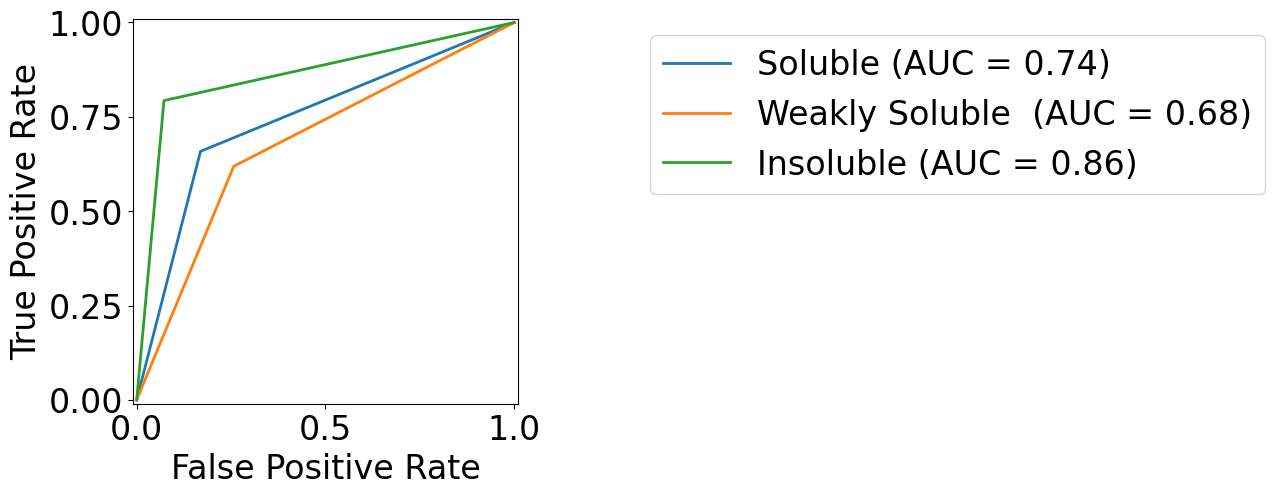

In [17]:
from sklearn.metrics import RocCurveDisplay
colors = [cmap(0), cmap(1), cmap(2)]
target_names = {
    0: r"Soluble",
    1: "Weakly Soluble ",
    2: r"Insoluble"
}

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

for class_id, color in zip(range(n_class), colors):
    RocCurveDisplay.from_predictions(
        np.array(y_test_true)==class_id,
        np.array(y_test_pred)==class_id,
        name=f"{target_names[class_id]}",
        color=color,
        ax=ax,
    )
_ = ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
)

ax.legend(bbox_to_anchor=(1.3, 1))